# 02. Feature Engineering & Feature Selection
**Project**: PharmaGuard ADR Severity Prediction  
**Objective**: Construct domain-specific pharmacodynamic interaction features, measure Mutual Information, and apply Recursive Feature Elimination with Cross-Validation (RFECV).


In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add src to system path to import project modules
sys.path.append(os.path.abspath(".."))

from src.data.preprocessing import PharmaDataCleaner
from src.features.build_features import PharmaFeatureEngineer
from sklearn.feature_selection import mutual_info_classif, RFECV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
print("Modules imported successfully.")


Modules imported successfully.


## 1. Load Data & Apply Preprocessing Cleaner


In [2]:
raw_data_path = os.path.join("..", "data", "raw", "pharma_adverse_events.csv")
df = pd.read_csv(raw_data_path)
print(f"Loaded raw records: {df.shape}")

# Preprocessing: Imputation and clinical bounds checking
cleaner = PharmaDataCleaner(clip_outliers=True)
df_clean = cleaner.fit_transform(df)
print("Data cleaned. Missing values remaining:", df_clean.isna().sum().sum())


Loaded raw records: (1000, 16)
Data cleaned. Missing values remaining: 0


## 2. Execute Domain Feature Engineering
Using `PharmaFeatureEngineer`, we generate:
1. `dose_intensity_mg_per_kg`: Daily dose scaled to patient weight.
2. `cumulative_dose_mg`: Cumulative drug exposure over treatment duration.
3. `polypharmacy_burden`: Concomitant medication count multiplied by the interaction index.
4. `organ_dysfunction_score`: Composite risk score (renal impairment + hepatic impairment + geriatric age >= 65).
5. `onset_to_duration_ratio`: Latency relative to treatment timeline.


In [3]:
engineer = PharmaFeatureEngineer()
df_featured = engineer.transform(df_clean)

engineered_cols = [
    'dose_intensity_mg_per_kg', 
    'cumulative_dose_mg', 
    'polypharmacy_burden', 
    'organ_dysfunction_score', 
    'onset_to_duration_ratio'
]
df_featured[engineered_cols].head(10)


,dose_intensity_mg_per_kg,cumulative_dose_mg,polypharmacy_burden,organ_dysfunction_score,onset_to_duration_ratio
0,2.062027,7087.6,8.00,0,0.346154
1,1.519630,3684.8,1.46,1,1.000000
2,0.902655,3549.6,4.23,1,0.155172
3,2.409938,21650.4,10.92,1,0.247312
4,7.863955,32520.6,10.86,0,0.431034
5,5.386881,26156.0,6.12,0,0.292308
6,5.943197,39141.3,0.00,1,0.275862
7,6.362822,62502.0,4.83,0,0.136364
8,2.127336,8558.7,3.60,0,0.617021
9,2.637374,10966.2,0.00,1,0.619048


## 3. Visualizing Engineered Feature Separation


/tmp/ipykernel_18297/3061396923.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_featured, x='serious_adverse_event', y='polypharmacy_burden',
/tmp/ipykernel_18297/3061396923.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Non-Serious', 'Serious'])
/tmp/ipykernel_18297/3061396923.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dysfunction_rates.index, y=dysfunction_rates.values, ax=axes[2], palette='Blues_r')


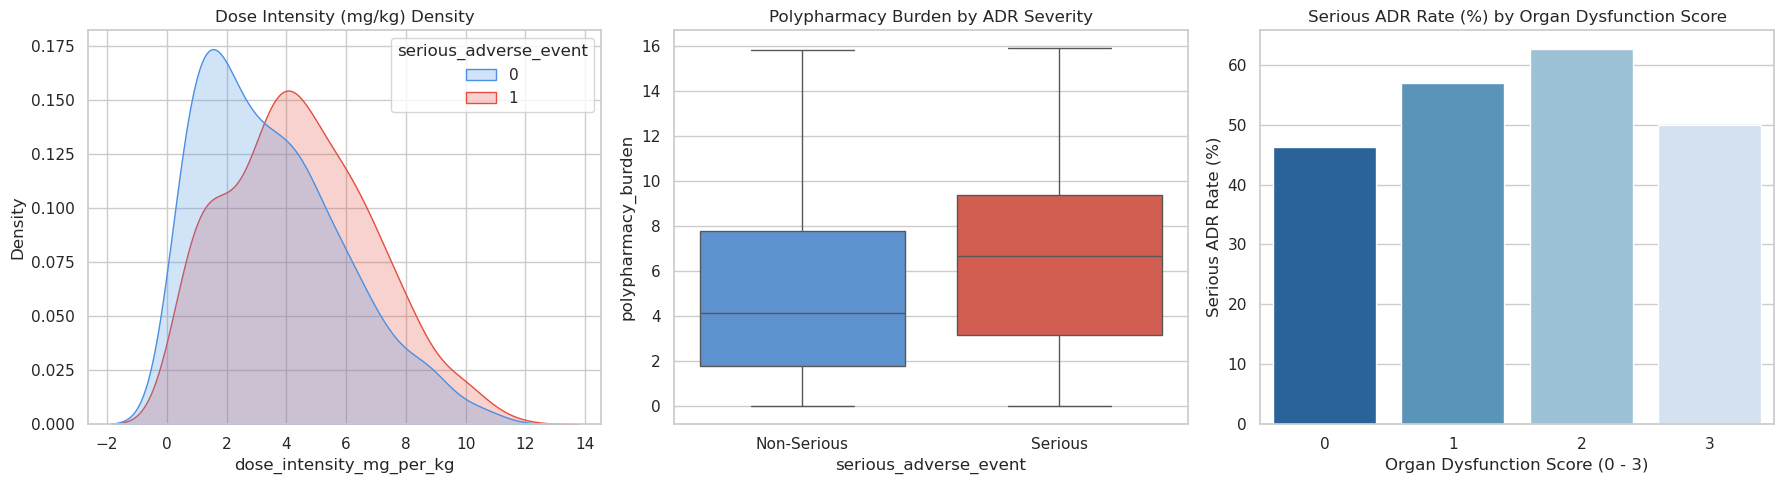

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Dose Intensity
sns.kdeplot(data=df_featured, x='dose_intensity_mg_per_kg', hue='serious_adverse_event', 
            common_norm=False, fill=True, ax=axes[0], palette=['#4A90E2', '#E74C3C'])
axes[0].set_title('Dose Intensity (mg/kg) Density')

# Polypharmacy Burden
sns.boxplot(data=df_featured, x='serious_adverse_event', y='polypharmacy_burden', 
            ax=axes[1], palette=['#4A90E2', '#E74C3C'])
axes[1].set_title('Polypharmacy Burden by ADR Severity')
axes[1].set_xticklabels(['Non-Serious', 'Serious'])

# Organ Dysfunction Composite Score
dysfunction_rates = df_featured.groupby('organ_dysfunction_score')['serious_adverse_event'].mean() * 100
sns.barplot(x=dysfunction_rates.index, y=dysfunction_rates.values, ax=axes[2], palette='Blues_r')
axes[2].set_title('Serious ADR Rate (%) by Organ Dysfunction Score')
axes[2].set_xlabel('Organ Dysfunction Score (0 - 3)')
axes[2].set_ylabel('Serious ADR Rate (%)')

plt.tight_layout()
plt.show()


## 4. Mutual Information Ranking


/tmp/ipykernel_18297/2767929456.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mi_df.head(15), x='Mutual_Information', y='Feature', palette='viridis')


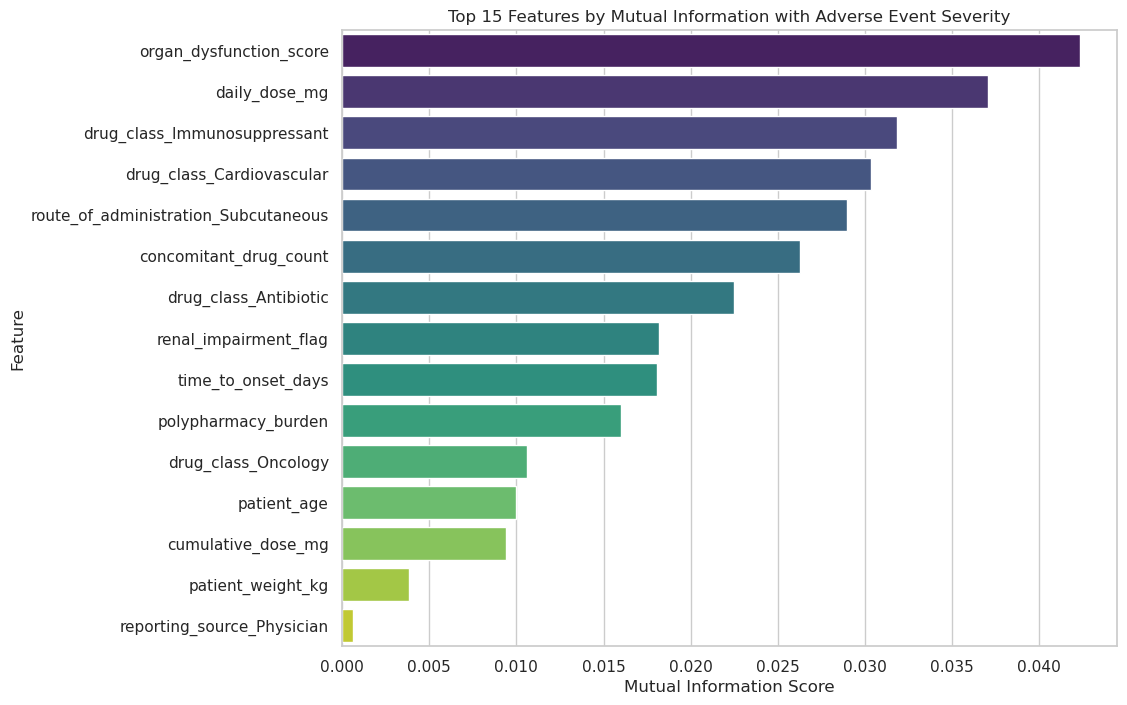

,Feature,Mutual_Information
0,organ_dysfunction_score,0.042347
1,daily_dose_mg,0.037084
2,drug_class_Immunosuppressant,0.031847
3,drug_class_Cardiovascular,0.030331
4,route_of_administration_Subcutaneous,0.028964
5,concomitant_drug_count,0.026295
6,drug_class_Antibiotic,0.022472
7,renal_impairment_flag,0.018156
8,time_to_onset_days,0.018063
9,polypharmacy_burden,0.015995


In [5]:
# Prepare numeric and one-hot encoded dataset for feature ranking
drop_cols = ['report_id', 'report_date', 'serious_adverse_event']
X = df_featured.drop(columns=[col for col in drop_cols if col in df_featured.columns])
y = df_featured['serious_adverse_event']

# Encode categoricals for selection algorithms
X_encoded = pd.get_dummies(X, drop_first=True)

# Compute Mutual Information
mi_scores = mutual_info_classif(X_encoded, y, random_state=42)
mi_df = pd.DataFrame({'Feature': X_encoded.columns, 'Mutual_Information': mi_scores})
mi_df = mi_df.sort_values(by='Mutual_Information', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 8))
sns.barplot(data=mi_df.head(15), x='Mutual_Information', y='Feature', palette='viridis')
plt.title('Top 15 Features by Mutual Information with Adverse Event Severity')
plt.xlabel('Mutual Information Score')
plt.show()

display(mi_df.head(15))


## 5. Recursive Feature Elimination with Cross-Validation (RFECV)


Optimal Number of Features Selected: 22


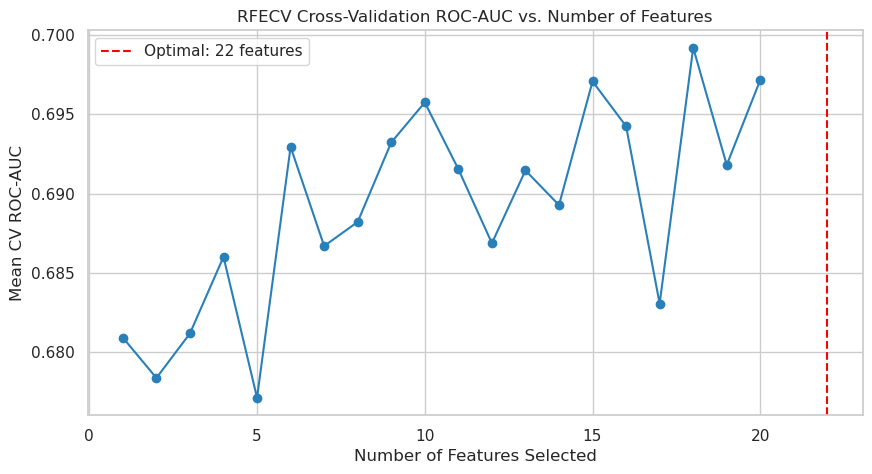

In [6]:
base_rf = RandomForestClassifier(
    n_estimators=50, 
    max_depth=6, 
    class_weight='balanced', 
    random_state=42, 
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rfecv = RFECV(
    estimator=base_rf,
    step=1,
    cv=cv,
    scoring='roc_auc',
    min_features_to_select=5,
    n_jobs=-1
)

rfecv.fit(X_encoded, y)

print(f"Optimal Number of Features Selected: {rfecv.n_features_}")

# Plot RFECV validation curve
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), rfecv.cv_results_['mean_test_score'], marker='o', color='#2980B9')
plt.title('RFECV Cross-Validation ROC-AUC vs. Number of Features')
plt.xlabel('Number of Features Selected')
plt.ylabel('Mean CV ROC-AUC')
plt.axvline(rfecv.n_features_, color='red', linestyle='--', label=f'Optimal: {rfecv.n_features_} features')
plt.legend()
plt.show()


## 6. Export Selected Features to Processed Storage


In [7]:
selected_feature_names = X_encoded.columns[rfecv.support_].tolist()
print("Selected Features for Production Pipeline:")
for f in selected_feature_names:
    print(f" - {f}")

# Save the curated dataset for modeling
processed_dir = os.path.join("..", "data", "processed")
os.makedirs(processed_dir, exist_ok=True)
output_path = os.path.join(processed_dir, "pharma_features_selected.csv")

final_export = X_encoded[selected_feature_names].copy()
final_export['serious_adverse_event'] = y.values
final_export.to_csv(output_path, index=False)

print(f"\nProcessed dataset successfully exported to: {output_path}")
print(f"Export dimensions: {final_export.shape[0]} rows x {final_export.shape[1]} columns")


Selected Features for Production Pipeline:
 - patient_age
 - patient_weight_kg
 - daily_dose_mg
 - treatment_duration_days
 - concomitant_drug_count
 - interaction_risk_index
 - renal_impairment_flag
 - time_to_onset_days
 - dose_intensity_mg_per_kg
 - cumulative_dose_mg
 - polypharmacy_burden
 - organ_dysfunction_score
 - onset_to_duration_ratio
 - patient_sex_Male
 - drug_class_Antibiotic
 - drug_class_CNS / Neurological
 - drug_class_Cardiovascular
 - drug_class_Immunosuppressant
 - route_of_administration_Oral
 - route_of_administration_Subcutaneous
 - reporting_source_Pharmacist
 - reporting_source_Physician

Processed dataset successfully exported to: ../data/processed/pharma_features_selected.csv
Export dimensions: 1000 rows x 23 columns
